# Практикум №5
**Варіант 2**  
    
**Виконали:**   
- Сачек Владислава, КА-31
- Богданова Олександра, КА-32
- Ревенко Ірина, КА-32   

**Тема:** Побудова та оцiнювання ансамблiв моделей класифiкацiї та регресiї з використанням бiблiотеки Scikit-Learn Python
   
**Завдання:** Побудувати та оцінити ансамбль моделей класифікації на основі методу ExtraTreesClassifier з використанням бібліотеки Scikit-Learn. Дослідити вплив різних значень параметрів max_depth, max_features та min_samples_split на якість класифікації.
*Початковi данi:*
(а) dataset_Malicious_and_Benign_Websites

Початкові дані були взяті з ресурсу: https://www.kaggle.com/datasets/aksingh2411/dataset-of-malicious-and-benign-webpages/data

### Опис методу побудови ансамблю, який використовувався - ExtraTreesClassifier
>ExtraTreesClassifier - це ансамблевий метод класифікації, який належить до сімейства деревних ансамблів. Він поєднує прогнози від великої кількості незалежних дерев рішень, щоб досягти вищої точності та стабільності порівняно з одним деревом. ExtraTrees використовує весь початковий тренувальний набір для кожного дерева, що зменшує зміщення ансамблю.   
>
>ExtraTrees обирає випадковий піднабір ознак, для кожної обраної ознаки обирає випадковий поріг поділу і з усіх цих випадкових порогів обирається той, який забезпечує найкращий поділ. Цей додатковий рівень випадковості призводить до того, що дисперсія зменшується, а швидкість зростає.

### Імпорт бібліотек та налаштування.

Встановлюємо seed для відтворюваності результатів.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, ConfusionMatrixDisplay
import time
from mlxtend.evaluate import bias_variance_decomp

np.random.seed(42)


### Завантаження початкових даних

Завантажуємо CSV файл з датасетом. Виводимо базову інформацію про розмір.

In [2]:
df = pd.read_csv('Webpages_Classification_test_data.csv')

print(f"Розмір датасету: {df.shape}")
print(f"Кількість рядків: {df.shape[0]}")
print(f"Кількість ознак: {df.shape[1]}")

Розмір датасету: (361934, 12)
Кількість рядків: 361934
Кількість ознак: 12


### Первинний аналіз 

Переглянемо структуру даних, типи зміних, статистику та пропущені значення.

In [3]:
print("Перші 5 рядків:")
print(df.head())

print("\nІнформація про датасет:")
print(df.info())

print("\nСтатистика:")
print(df.describe())

print("\nПропущені значення:")
print(df.isnull().sum())

print("\nНазви колонок:")
print(df.columns.tolist())

Перші 5 рядків:
   Unnamed: 0                                                url  url_len  \
0           0               http://www.dutchthewiz.com/freeware/       36   
1           1                   http://www.collectiblejewels.com       32   
2           2                        http://www.deadlinedata.com       27   
3           3  http://www.mil.fi/maavoimat/kalustoesittely/00...       56   
4           4           http://www.avclub.com/content/node/24539       40   

            ip_add    geo_loc  tld      who_is https  js_len  js_obf_len  \
0    175.67.214.68      China  com    complete   yes    38.5         0.0   
1  188.120.171.121     Sweden  com  incomplete   yes   187.0         0.0   
2     193.51.170.1     France  com    complete   yes    31.0         0.0   
3     13.237.35.44  Australia   fi    complete   yes   152.0         0.0   
4    220.193.62.89      China  com    complete   yes   150.0         0.0   

                                             content label  
0  

### Аналіз розподілу класів

Перевіримо розподіл між класами malicious та benign. Побудуємо графік.

Розподіл класів:
label
good    353872
bad       8062
Name: count, dtype: int64

Відсотки:
label
good    97.772522
bad      2.227478
Name: proportion, dtype: float64


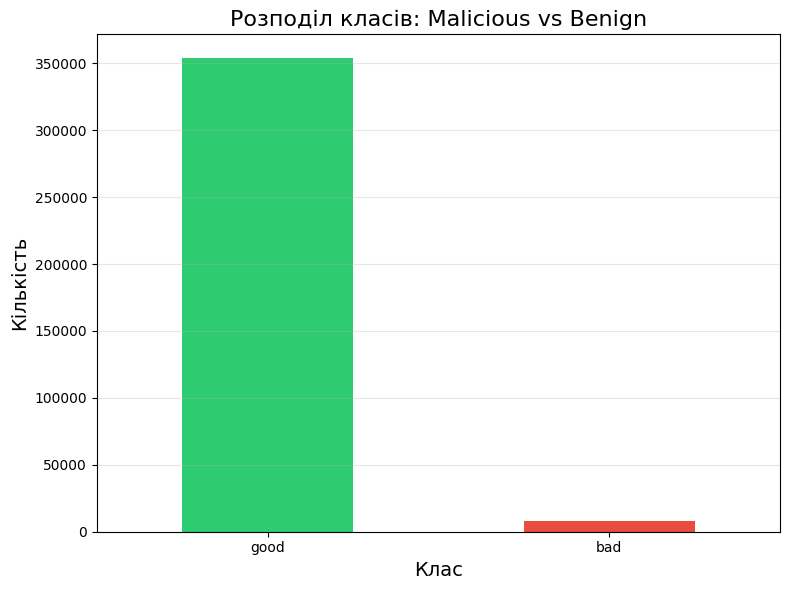

In [4]:
TARGET_COLUMN = 'label'

print("Розподіл класів:")
print(df[TARGET_COLUMN].value_counts())
print("\nВідсотки:")
print(df[TARGET_COLUMN].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 6))
df[TARGET_COLUMN].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Розподіл класів: Malicious vs Benign', fontsize=16)
plt.xlabel('Клас', fontsize=14)
plt.ylabel('Кількість', fontsize=14)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

> Датасет сильно незбалансований. Клас good становить 97.77% всіх даних (353872 зразки), тоді як клас bad лише 2.23% (8062 зразки). Така диспропорція може впливати на якість класифікації - модель може бути схильна до передбачення класу більшості. Для коректного розбиття використовується параметр stratify, щоб зберегти пропорції класів у всіх наборах даних.

### Підготовка ознак

Відокремлюємо ознаки від міток. Видаляємо текстові колонки та службову колонку Unnamed: 0. Кодуємо мітки класів у числа.

In [5]:
TARGET_COLUMN = 'label'

X = df.drop(columns=[TARGET_COLUMN, 'Unnamed: 0'])
y = df[TARGET_COLUMN]

text_columns = ['url', 'ip_add', 'geo_loc', 'tld', 'content']
X = X.drop(columns=text_columns)

le_whois = LabelEncoder()
X['who_is'] = le_whois.fit_transform(X['who_is'])

le_https = LabelEncoder()
X['https'] = le_https.fit_transform(X['https'])

print(f"Кількість числових ознак: {X.shape[1]}")
print(f"Ознаки: {X.columns.tolist()}")

le = LabelEncoder()
y = le.fit_transform(y)
print(f"Класи: {le.classes_}")
print(f"Кодування: 0 = {le.classes_[0]}, 1 = {le.classes_[1]}")

Кількість числових ознак: 5
Ознаки: ['url_len', 'who_is', 'https', 'js_len', 'js_obf_len']
Класи: ['bad' 'good']
Кодування: 0 = bad, 1 = good


> Після видалення текстових колонок залишилось 5 числових ознак для аналізу. Колонки who_is та https закодовані з текстових значень у числові. Цільова змінна label має два класи: bad (шкідливі сайти) закодовано як 0, good (безпечні сайти) як 1.

### Нормалізація даних

Стандартизуємо ознаки для кращої роботи алгоритмів.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Дані нормалізовано")
print(X_scaled.head())

Дані нормалізовано
    url_len    who_is     https    js_len  js_obf_len
0  0.010583 -0.524686  0.526677 -0.893575   -0.134462
1 -0.266945  1.905901  0.526677  0.756518   -0.134462
2 -0.613854 -0.524686  0.526677 -0.976913   -0.134462
3  1.398220 -0.524686  0.526677  0.367607   -0.134462
4  0.288110 -0.524686  0.526677  0.345384   -0.134462


> Всі 5 ознак приведено до стандартного масштабу із середнім значенням 0 та стандартним відхиленням 1. Після нормалізації значення знаходяться приблизно в діапазоні від -1 до 2. Це забезпечує однаковий вплив всіх ознак на модель незалежно від їх початкового масштабу.

### Візуалізація через PCA

Зводимо дані до двох головних компонент для візуалізації на площині.

Пояснена дисперсія: [0.39258934 0.19995721]
Сумарна: 0.5925


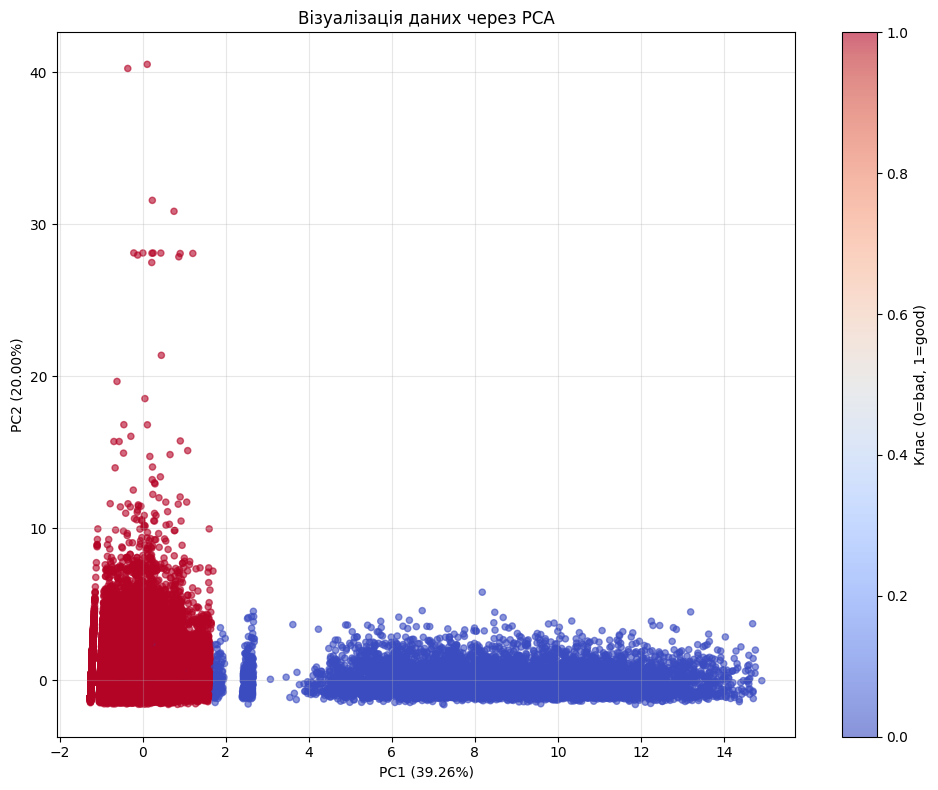

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Пояснена дисперсія: {pca.explained_variance_ratio_}")
print(f"Сумарна: {sum(pca.explained_variance_ratio_):.4f}")

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6, s=20)
plt.colorbar(label='Клас (0=bad, 1=good)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title('Візуалізація даних через PCA')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> Перші дві головні компоненти пояснюють 59.25% дисперсії даних (PC1 = 39.26%, PC2 = 19.99%). На графіку видно чіткий поділ між класами: червоні точки (bad - шкідливі сайти) утворюють компактний кластер у лівій верхній частині, тоді як сині точки (good - безпечні сайти) розташовані більш рівномірно. Незважаючи на незбалансованість класів (97.7% good проти 2.2% bad), PCA демонструє, що класи мають відмінні характеристики у просторі ознак, що є позитивним сигналом для класифікації.

### Розбиття на навчальний, валідаційний та тестовий набори

Розділяємо дані у пропорції 60-20-20 зі збереженням розподілу класів.

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.4, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Навчальний набір: {X_train.shape}")
print(f"Валідаційний набір: {X_val.shape}")
print(f"Тестовий набір: {X_test.shape}")
print(f"\nРозподіл класів у навчальному наборі:")
print(pd.Series(y_train).value_counts())

Навчальний набір: (217160, 5)
Валідаційний набір: (72387, 5)
Тестовий набір: (72387, 5)

Розподіл класів у навчальному наборі:
1    212323
0      4837
Name: count, dtype: int64


> Дані розділено у пропорції 60-20-20: навчальний набір містить 217160 зразків, валідаційний та тестовий по 72387 зразків. Параметр stratify забезпечив збереження пропорції класів з оригінального датасету - у навчальному наборі 97.77% good (212323) та 2.23% bad (4837). Така незбалансованість потребує уважного аналізу результатів.

### Базова модель DecisionTree

Тренуємо окреме дерево рішень для подальшого порівняння з ансамблем.

In [9]:
base_tree = DecisionTreeClassifier(random_state=42)

start_time = time.time()
base_tree.fit(X_train, y_train)
base_train_time = time.time() - start_time

y_pred_base = base_tree.predict(X_val)
base_accuracy = accuracy_score(y_val, y_pred_base)
base_f1 = f1_score(y_val, y_pred_base, average='weighted')

print("Базова модель DecisionTree:")
print(f"Accuracy: {base_accuracy:.4f}")
print(f"F1-score: {base_f1:.4f}")
print(f"Час навчання: {base_train_time:.4f} сек")

Базова модель DecisionTree:
Accuracy: 0.9987
F1-score: 0.9986
Час навчання: 0.0868 сек


> Окреме дерево рішень показало дуже високу точність 99.87% та F1-score 99.86% на валідаційному наборі. Час навчання становить лише 0.09 секунди. Така висока якість може бути зумовлена чіткою лінійною розділеністю класів (що підтверджує PCA візуалізація) або схильністю моделі до передбачення класу більшості. Ці метрики слугуватимуть базою для порівняння з ансамблем ExtraTrees.

### Дослідження параметру max_depth

Перевіряємо різні значення max_depth від 3 до None.

In [10]:
max_depth_values = [3, 5, 10, 15, 20, 25, 30, None]
depth_results = {'max_depth': [], 'accuracy': [], 'f1_score': [], 'train_time': []}

for depth in max_depth_values:
    model = ExtraTreesClassifier(
        n_estimators=100, 
        max_depth=depth, 
        random_state=42, 
        n_jobs=-1
    )
    
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    
    depth_results['max_depth'].append(str(depth))
    depth_results['accuracy'].append(acc)
    depth_results['f1_score'].append(f1)
    depth_results['train_time'].append(train_time)
    
    print(f"max_depth={depth}: Accuracy={acc:.4f}, F1={f1:.4f}, Time={train_time:.2f}s")

depth_df = pd.DataFrame(depth_results)
print("\n")
print(depth_df)

max_depth=3: Accuracy=0.9975, F1=0.9974, Time=1.34s
max_depth=5: Accuracy=0.9978, F1=0.9977, Time=1.24s
max_depth=10: Accuracy=0.9988, F1=0.9988, Time=1.59s
max_depth=15: Accuracy=0.9988, F1=0.9988, Time=1.63s
max_depth=20: Accuracy=0.9988, F1=0.9988, Time=1.16s
max_depth=25: Accuracy=0.9987, F1=0.9987, Time=0.98s
max_depth=30: Accuracy=0.9987, F1=0.9987, Time=1.02s
max_depth=None: Accuracy=0.9987, F1=0.9987, Time=1.06s


  max_depth  accuracy  f1_score  train_time
0         3  0.997513  0.997441    1.343084
1         5  0.997803  0.997748    1.243349
2        10  0.998840  0.998824    1.588678
3        15  0.998784  0.998770    1.631094
4        20  0.998812  0.998799    1.156196
5        25  0.998715  0.998704    0.976369
6        30  0.998674  0.998662    1.018094
7      None  0.998674  0.998662    1.057081


> Результати показують чітку залежність якості класифікації від глибини дерев. При малих значенях (max_depth=3) точність становить 99.75%, що є найнижчим показником, але все одно дуже високим. Різке зростання якості спостерігається при збільшенні глибини до 10, де досягається максимальна точність 99.88% та F1-score 99.88%.
>
> Подальше збільшення max_depth (15, 20, 25, 30 та None) не призводить до покращення результатів - метрики стабілізуються на рівні 99.87%. Це свідчить про те, що дерева глибиною 10 вже достатньо для виявлення всіх важливих закономірностей у даних. Більш глибокі дерева можуть призводити до перенавчання, що видно з незначного зниження якості.

### Графік залежності від max_depth

Візуалізація впливу max_depth на якість моделі.

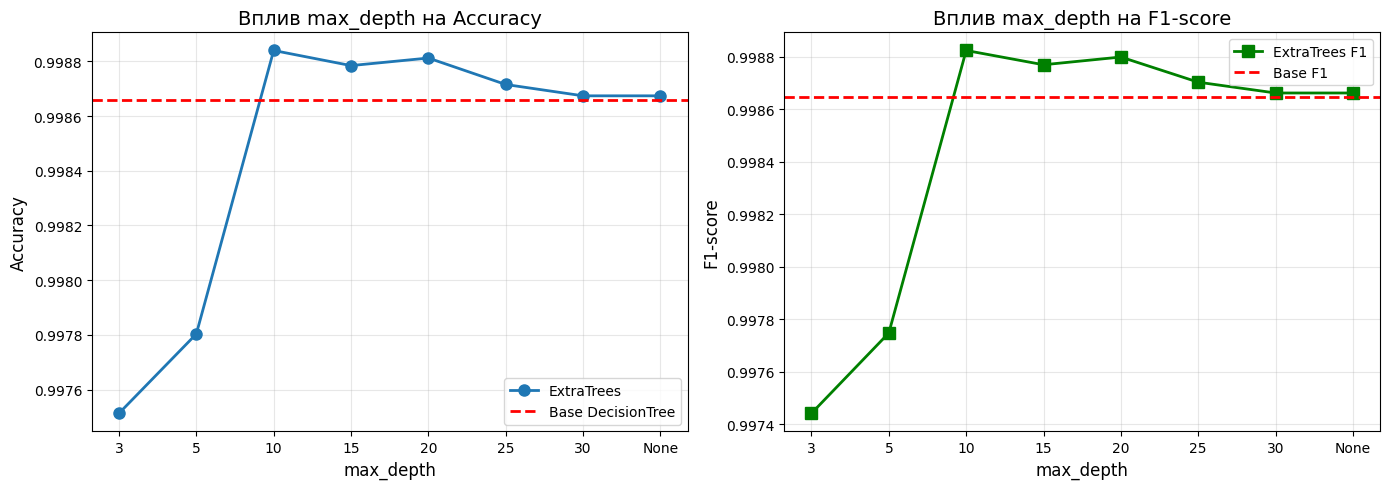

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(depth_df['max_depth'], depth_df['accuracy'], marker='o', linewidth=2, markersize=8, label='ExtraTrees')
axes[0].axhline(y=base_accuracy, color='r', linestyle='--', linewidth=2, label='Base DecisionTree')
axes[0].set_xlabel('max_depth', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Вплив max_depth на Accuracy', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(depth_df['max_depth'], depth_df['f1_score'], marker='s', linewidth=2, markersize=8, color='green', label='ExtraTrees F1')
axes[1].axhline(y=base_f1, color='r', linestyle='--', linewidth=2, label='Base F1')
axes[1].set_xlabel('max_depth', fontsize=12)
axes[1].set_ylabel('F1-score', fontsize=12)
axes[1].set_title('Вплив max_depth на F1-score', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

> Порівняння з базовою моделлю (червона пунктирна лінія на графіках) показує, що ансамбль ExtraTrees при max_depth=10-20 має невелику, але стабільну перевагу. При цьому час навчання зростає з 0.97 секунд до 1.63 секунд, що є прийнятним збільшенням.
>
> Оптимальним значенням є max_depth=10, яке забезпечує найкращий баланс між якістю класифікації (99.88%) та швидкістю навчання (1.58 сек).

### Дослідження параметру max_features

Тестуємо різні значення max_features.


In [12]:
max_features_values = ['sqrt', 'log2', 0.3, 0.5, 0.7, 1.0, None]
features_results = {'max_features': [], 'accuracy': [], 'f1_score': [], 'train_time': []}

for features in max_features_values:
    model = ExtraTreesClassifier(
        n_estimators=100, 
        max_features=features, 
        random_state=42, 
        n_jobs=-1
    )
    
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    
    features_results['max_features'].append(str(features))
    features_results['accuracy'].append(acc)
    features_results['f1_score'].append(f1)
    features_results['train_time'].append(train_time)
    
    print(f"max_features={features}: Accuracy={acc:.4f}, F1={f1:.4f}, Time={train_time:.2f}s")

features_df = pd.DataFrame(features_results)
print("\n")
print(features_df)

max_features=sqrt: Accuracy=0.9987, F1=0.9987, Time=1.04s
max_features=log2: Accuracy=0.9987, F1=0.9987, Time=0.97s
max_features=0.3: Accuracy=0.9987, F1=0.9987, Time=0.97s
max_features=0.5: Accuracy=0.9987, F1=0.9987, Time=0.98s
max_features=0.7: Accuracy=0.9987, F1=0.9987, Time=1.75s
max_features=1.0: Accuracy=0.9987, F1=0.9987, Time=2.04s
max_features=None: Accuracy=0.9987, F1=0.9987, Time=1.46s


  max_features  accuracy  f1_score  train_time
0         sqrt  0.998674  0.998662    1.036325
1         log2  0.998674  0.998662    0.970305
2          0.3  0.998674  0.998662    0.970472
3          0.5  0.998674  0.998662    0.981106
4          0.7  0.998674  0.998662    1.750867
5          1.0  0.998674  0.998662    2.039023
6         None  0.998674  0.998662    1.456122


### Графік залежності від max_features

Візуалізація впливу max_features на продуктивність.

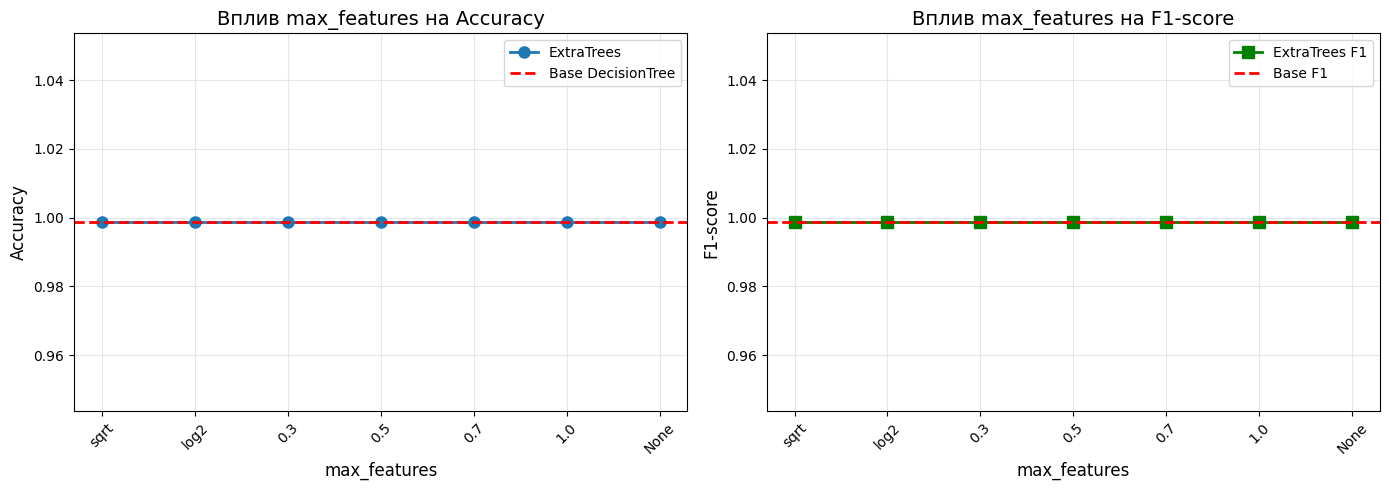

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(features_df['max_features'], features_df['accuracy'], marker='o', linewidth=2, markersize=8, label='ExtraTrees')
axes[0].axhline(y=base_accuracy, color='r', linestyle='--', linewidth=2, label='Base DecisionTree')
axes[0].set_xlabel('max_features', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Вплив max_features на Accuracy', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(features_df['max_features'], features_df['f1_score'], marker='s', linewidth=2, markersize=8, color='green', label='ExtraTrees F1')
axes[1].axhline(y=base_f1, color='r', linestyle='--', linewidth=2, label='Base F1')
axes[1].set_xlabel('max_features', fontsize=12)
axes[1].set_ylabel('F1-score', fontsize=12)
axes[1].set_title('Вплив max_features на F1-score', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

> Результати дослідження параметру max_features показують стабільну якість класифікації 99.87% для всіх протестованих значень. На відміну від max_depth, цей параметр не впливає на точність моделі на даному датасеті.
> 
> Таке явище пояснюється специфікою задачі: датасет містить лише 5 числових ознак, і навіть при обмеженні до 1-2 ознак на кожне розбиття (max_features=0.3 або sqrt), ансамбль зі 100 дерев покриває всі можливі комбінації ознак достатню кількість разів для точної класифікації.
> 
> Графіки демонструють горизонтальні лінії, що повністю співпадають з базовою моделлю. Це свідчить про високу інформативність кожної ознаки окремо - класи добре розділені навіть при використанні підмножини ознак.
>
> Час навчання варіюється від 0.97 секунд (max_features=0.3) до 2.03 секунди (max_features=1), що становить різницю у 28%. При цьому всі варіанти показують ідентичну якість класифікації.

### Дослідження параметру min_samples_spit

In [14]:
min_samples_split_values = [2, 5, 10, 20, 30, 50]

split_results = []

for mss in min_samples_split_values:
    model = ExtraTreesClassifier(
        n_estimators=100,
        max_features=features,
        min_samples_split=mss,
        random_state=42,
        n_jobs=-1
    )

    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    split_results.append({
        "min_samples_split": mss,
        "accuracy": acc,
        "f1_score": f1,
        "training_time_sec": round(train_time, 4)
    })

split_df = pd.DataFrame(split_results)
print(split_df)


   min_samples_split  accuracy  f1_score  training_time_sec
0                  2  0.998909  0.999442             1.3040
1                  5  0.998895  0.999435             1.3214
2                 10  0.998895  0.999435             1.4128
3                 20  0.998922  0.999449             1.3593
4                 30  0.998936  0.999456             1.7937
5                 50  0.999047  0.999513             1.6847


### Графік залежності від min_samples_split

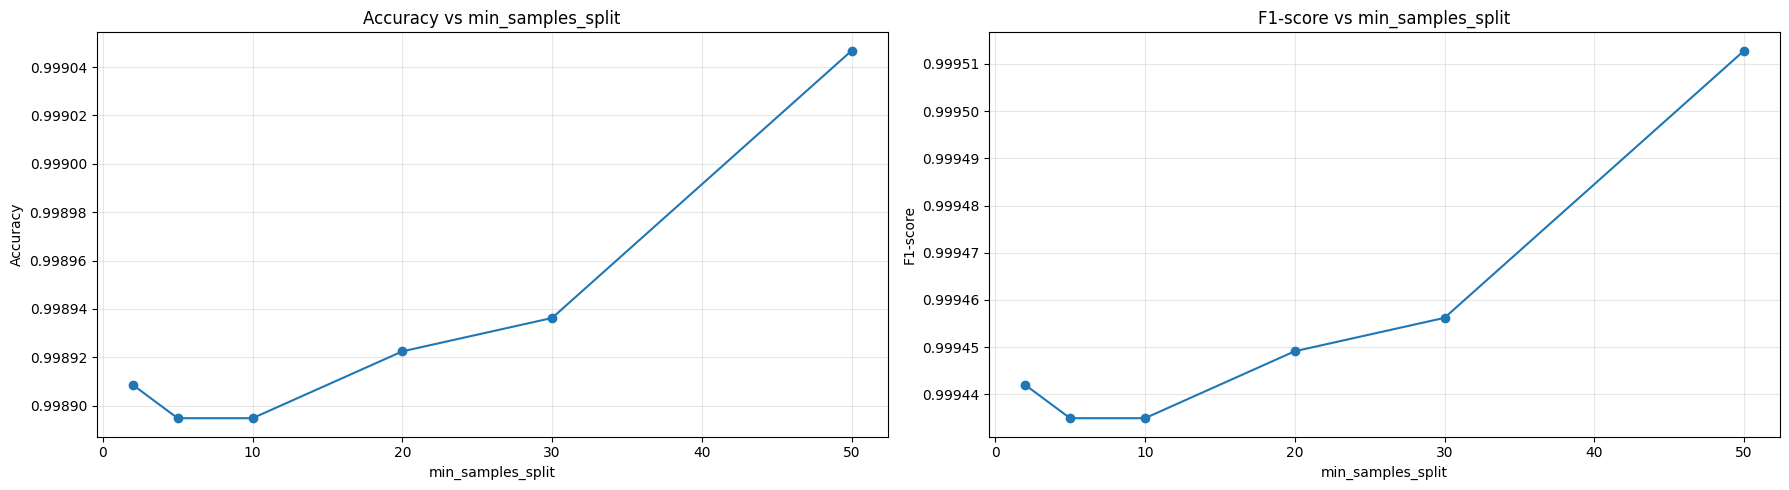

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Accuracy
axes[0].plot(split_df["min_samples_split"], split_df["accuracy"], marker='o')
axes[0].set_title("Accuracy vs min_samples_split")
axes[0].set_xlabel("min_samples_split")
axes[0].set_ylabel("Accuracy")
axes[0].grid(alpha=0.3)

# F1-score
axes[1].plot(split_df["min_samples_split"], split_df["f1_score"], marker='o')
axes[1].set_title("F1-score vs min_samples_split")
axes[1].set_xlabel("min_samples_split")
axes[1].set_ylabel("F1-score")
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()


Аналіз впливу параметра min_samples_split показав, що його збільшення позитивно впливає на якість моделі ExtraTreesClassifier. 
Як Accuracy, так і F1-score демонструють плавне зростання від значень 2–10 до значень 30–50. Це свідчить про те, що модель виграє від більш жорсткого критерію поділу вузлів, що зменшує надмірну глибину дерев та знижує ризик перенавчання. 
При цьому час навчання практично не змінюється, що означає відсутність компромісу між якістю та продуктивністю.
Отже, для даного датасета оптимальні значення min_samples_split знаходяться 
в області 30–50, де модель демонструє найвищі показники точності та F1-score.

### Проведемо дослідження залежності від кількості дерев:

In [16]:
n_values = [10, 30, 50, 100, 200, 300, 500, 700, 1000]

trees_results = []

for n in n_values:
    model = ExtraTreesClassifier(
        n_estimators=n,
        max_depth=10,           
        min_samples_split=50,   
        max_features=features,  
        random_state=42,
        n_jobs=-1
    )
    
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    trees_results.append({
        "n_estimators": n,
        "accuracy": acc,
        "f1_score": f1,
        "training_time_sec": round(train_time, 4)
    })

trees_df = pd.DataFrame(trees_results)
print(trees_df)


   n_estimators  accuracy  f1_score  training_time_sec
0            10  0.999047  0.999513             0.1473
1            30  0.999047  0.999513             0.4505
2            50  0.999047  0.999513             0.6828
3           100  0.999047  0.999513             1.5489
4           200  0.999047  0.999513             3.8681
5           300  0.999047  0.999513             4.9266
6           500  0.999047  0.999513             7.7341
7           700  0.999047  0.999513            10.1201
8          1000  0.999047  0.999513            13.1797


### Графіки залежності

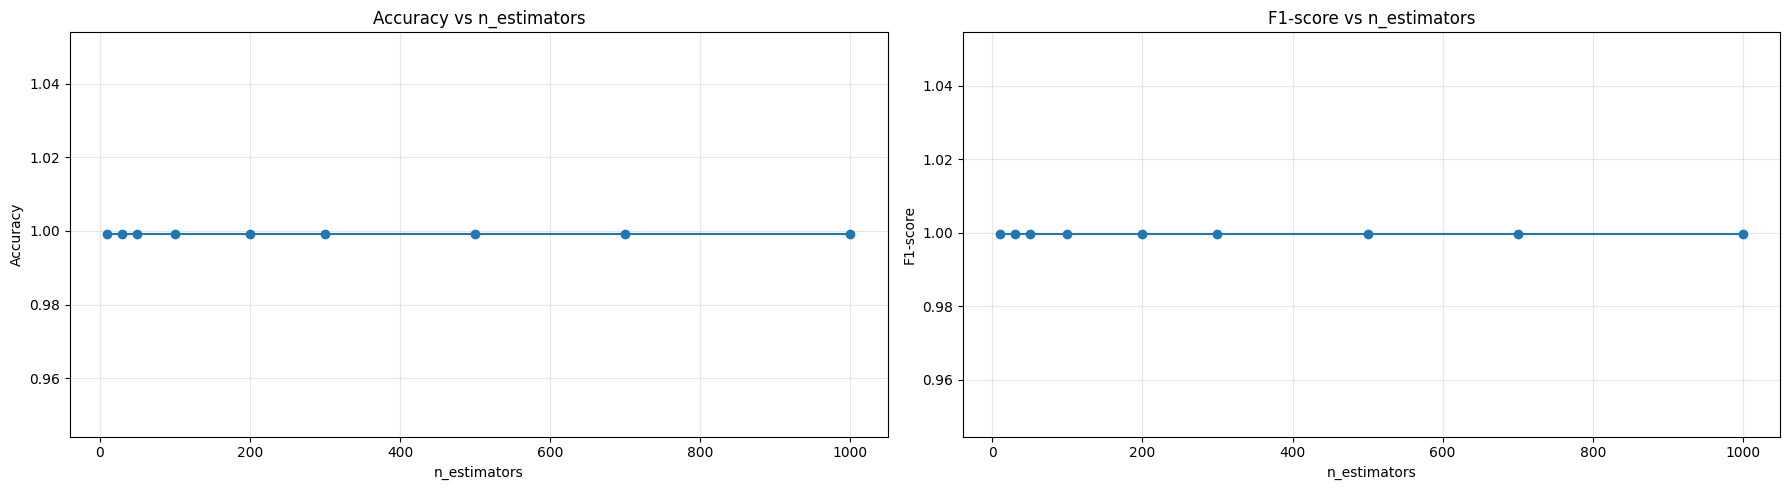

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Accuracy
axes[0].plot(trees_df["n_estimators"], trees_df["accuracy"], marker='o')
axes[0].set_title("Accuracy vs n_estimators")
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("Accuracy")
axes[0].grid(alpha=0.3)

# F1-score
axes[1].plot(trees_df["n_estimators"], trees_df["f1_score"], marker='o')
axes[1].set_title("F1-score vs n_estimators")
axes[1].set_xlabel("n_estimators")
axes[1].set_ylabel("F1-score")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Дослідження впливу кількості дерев (n_estimators) показало, що збільшення кількості дерев у моделі ExtraTreesClassifier не впливає на якість класифікації. Метрики Accuracy (0.999047) та F1-score (0.999513) залишаються абсолютно сталими для всіх протестованих значень від 10 до 1000 дерев.
Це означає, що модель досягає максимальної якості вже при дуже малій кількості дерев (10–30), а подальше збільшення лише підвищує час навчання, не приносячи жодного приросту точності.
Таким чином, оптимальним вибором є використання невеликої кількості дерев (30–50), оскільки це забезпечує мінімальний час навчання при тій самій 
максимальній якості класифікації.


### Тепер наведемо приклад границi рiшень decision boundaries на основi окремої моделi та ансамблю:

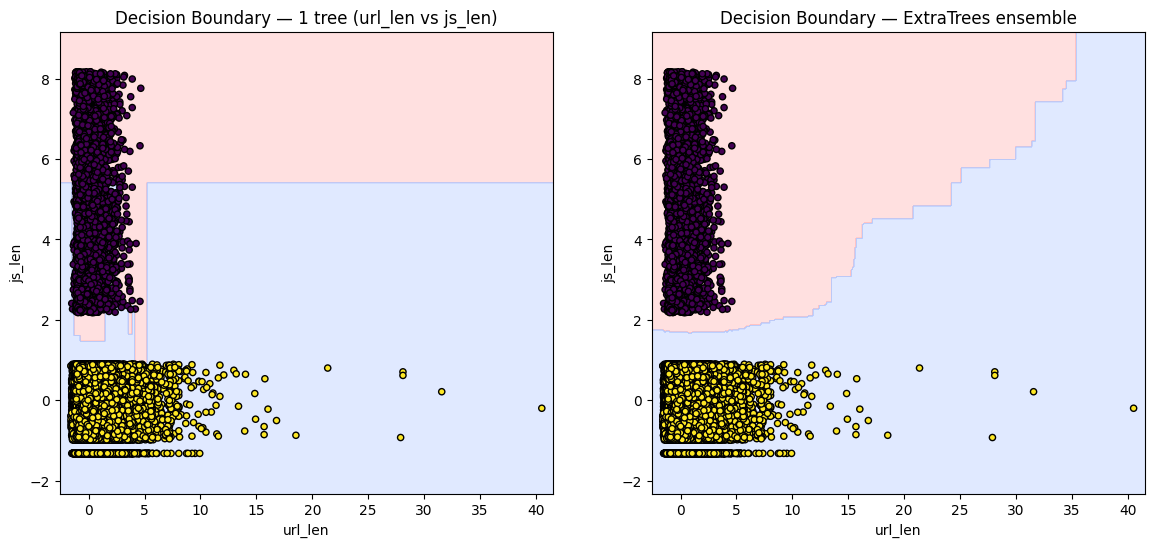

In [18]:
feature_x = "url_len"
feature_y = "js_len"

X2 = X_train[[feature_x, feature_y]].values
y2 = y_train

forest = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=50,
    random_state=42,
    n_jobs=-1
)
forest.fit(X2, y2)

tree00 = forest.estimators_[0]

x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

Z_tree   = tree00.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z_forest = forest.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cmap = ListedColormap(["#ffb3b3", "#b3caff"])

axes[0].contourf(xx, yy, Z_tree, alpha=0.4, cmap=cmap)
axes[0].scatter(X2[:, 0], X2[:, 1], c=y2, edgecolor='k', s=20)
axes[0].set_title(f"Decision Boundary — 1 tree ({feature_x} vs {feature_y})")
axes[0].set_xlabel(feature_x)
axes[0].set_ylabel(feature_y)

axes[1].contourf(xx, yy, Z_forest, alpha=0.4, cmap=cmap)
axes[1].scatter(X2[:, 0], X2[:, 1], c=y2, edgecolor='k', s=20)
axes[1].set_title(f"Decision Boundary — ExtraTrees ensemble")
axes[1].set_xlabel(feature_x)
axes[1].set_ylabel(feature_y)

plt.show()



Окреме дерево формує різкі, фрагментовані границі рішень, що свідчить про високу варіативність моделі та схильність до перенавчання. У свою чергу ансамбль ExtraTreesClassifier забезпечує значно плавніші та стійкіші decision boundaries завдяки усередненню рішень багатьох дерев. Це робить ансамблеву модель більш стабільною, узагальнюючою та менш чутливою до локальних аномалій у даних.

### Розрахунок зміщення та дисперсії

In [19]:
X_train_np = X_train.values
X_test_np = X_test.values

def calc_bias_var(model, name):
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        model, X_train_np, y_train, X_test_np, y_test,
        loss='0-1_loss', 
        random_seed=42, 
        num_rounds=50
    )
    print(f"--- {name} ---")
    print(f"Average Expected Loss: {avg_expected_loss:.4f}")
    print(f"Bias: {avg_bias:.4f}")
    print(f"Variance: {avg_var:.4f}\n")

calc_bias_var(base_tree, "Decision Tree (Single)")
calc_bias_var(forest, "ExtraTrees Ensemble")

--- Decision Tree (Single) ---
Average Expected Loss: 0.0012
Bias: 0.0012
Variance: 0.0005

--- ExtraTrees Ensemble ---
Average Expected Loss: 0.0010
Bias: 0.0010
Variance: 0.0000



Обидві моделі мають надзвичайно низьке зміщення (0.0012 для дерева та 0.0010 для ансамблю), що свідчить про високу передбачувальну силу ознак та майже ідеальне моделювання залежності. Одиничне дерево рішень має низьке зміщення, оскільки воно може моделювати дуже складні, нелінійні границі рішень і добре підганяється під тренувальні дані. 
   
Дисперсія вимірює, наскільки чутливим є прогноз моделі до невеликих змін у навчальному наборі. Decision Tree має дисперсію 0.0005, що означає, що його прогноз може коливатися, хоч і не сильно. ExtraTrees, завдяки усередненню прогнозів великої кількості незалежно навчених і рандомізованих дерев, повністю нейтралізував цей ефект: дисперсія практично дорівнює нулю (0.0000). Цей результат гарантує, що прогноз ансамблю є максимально стабільним і надійним, незалежно від невеликих варіацій у навчальному наборі.

### Розрахунок і порівняння метрик якості для окремого дерева і ансамблю.
Рахуємо на тестовому наборі метрики accuracy, precision, recall, f1_score та матрицю помилок для ансаблю і індивідуальної моделі:

Порівняльна таблиця метрик якості:


,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1 Score (Weighted),Time
0,Decision Tree,0.99891,0.99890,0.99891,0.99890,0.05881
1,ExtraTrees,0.99905,0.99905,0.99905,0.99904,1.00989


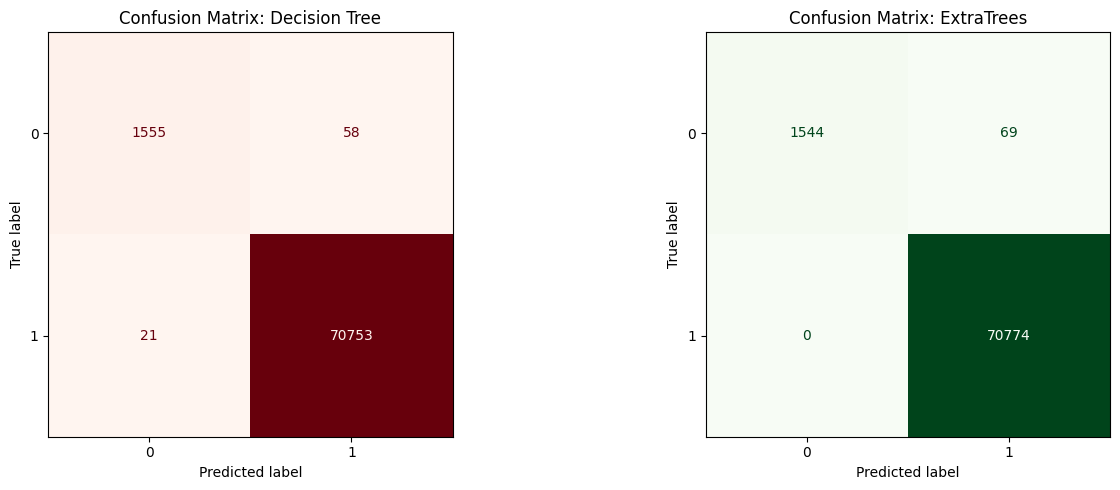

In [20]:
tree_model = DecisionTreeClassifier(random_state=1)
start_time_tree = time.time()
tree_model.fit(X_train, y_train)
tree_train_time = time.time() - start_time_tree

extratrees_model= ExtraTreesClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=50,
    max_features='sqrt',
    random_state=1,
    n_jobs=-1
)
start_time_et = time.time()
extratrees_model.fit(X_train, y_train)
et_train_time = time.time() - start_time_et

y_pred_tree = tree_model.predict(X_test)
y_pred_et = extratrees_model.predict(X_test)

metrics_data = {
    'Model': ['Decision Tree', 'ExtraTrees'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_et)
    ],
    'Precision (Weighted)': [
        precision_score(y_test, y_pred_tree, average='weighted'),
        precision_score(y_test, y_pred_et, average='weighted')
    ],
    'Recall (Weighted)': [
        recall_score(y_test, y_pred_tree, average='weighted'),
        recall_score(y_test, y_pred_et, average='weighted')
    ],
    'F1 Score (Weighted)': [
        f1_score(y_test, y_pred_tree, average='weighted'),
        f1_score(y_test, y_pred_et, average='weighted')
    ],
    'Time': [tree_train_time, et_train_time]
}

metrics_df = pd.DataFrame(metrics_data)
print("Порівняльна таблиця метрик якості:")
display(metrics_df.round(5))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree, ax=axes[0], cmap='Reds', colorbar=False)
axes[0].set_title('Confusion Matrix: Decision Tree')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_et, ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix: ExtraTrees')

plt.tight_layout()
plt.show()

Час навчання ансамблю ExtraTrees (~1 сек) очікувано є значно вищим, ніж час навчання окремого дерева рішень (~0.06 сек). Ця різниця пов'язана з тим, що ансамбль повинен послідовно або паралельно побудувати 100 окремих дерев, тоді як базова модель будує лише одне. Проте, оскільки ансамблеві методи добре піддаються паралелізації, час навчання все ще лишається доволі низьким.   
   
Отримані метрики якості (Accuracy, Precision, Recall, F1) для обох моделей є винятково високими (~0.999), підтверджуючи, що задача класифікації добре розв'язується. Проте, на незбалансованому датасеті, найбільш інформативним є порівняння матриць помилок: ансамбль повністю ліквідував помилки II роду - шкідливий сайт помилково позначений як безпечний (FN=0), що є критичним для незбалансованих даних, де ідентифікація рідкісного класу є найважливішою. Він помилково класифікував 69 прикладів мажоритарного класу (FP=69), що є невеликим зростанням порівняно з Decision Tree (FP=21), але у цій задачі важливішим було зменшення числа FN.

## Висновки
>Продемонстровані переваги ансамблю:
>- ансамбль досяг трохи вищих метрик якості, наприклад, Accuracy 0.99905 проти 0.99891 і нижчих очікуваних втрат (0.0010 проти 0.0012);
>- ідеальне узагальнення значно меншого класу шкідливих сайтів: ExtraTrees не пропустив жодного прикладу шкідливого сайту на тестовому наборі (FN=0), що дуже важливо у контексті кібербезпеки;
>- ансамбль досяг нульової дисперсії, що робить його прогноз максимально стабільним і надійним, незалежно від невеликих варіацій у навчальному наборі.   
   
>Таким чином, ансамбль ExtraTrees виконується краще порівняно з окремою моделлю, оскільки він забезпечив найвищу надійність та найкращу ідентифікацію критичного меншого класу при мінімальному зростанні обчислювального часу.